# Least Squares Regression In-Class Examples

This code was provided by Bao Wang for in-class use. He stated that much of the code came from AI but was provided to us for download and future reference.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
A = np.array([[1,2],
              [2,1],
              [3,2]])

b = np.array([0,1,1])

x, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

print(f"Least-squares solution (x_1, x_2): {x}")
print(f"Sum of squared residuals: {residuals}")

Least-squares solution (x_1, x_2): [ 0.57692308 -0.30769231]
Sum of squared residuals: [0.03846154]


In [11]:
num_points = 30

x = np.array([(i - 1) / 29 for i in range(1, num_points+1)])

# Epsilon to generate noise so that it isn't a perfect linear solution
epsilon = np.random.normal(loc=0, scale=0.1, size=num_points)
y = 2 * x + 1 + epsilon

A = np.vstack([x, np.ones(len(x))]).T

Y = y

coefficients, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)

a_fit, b_fit = coefficients[0], coefficients[1]

print(f"Fitted line: y = {a_fit:.4f}x + {b_fit:.4f}")

Fitted line: y = 2.0098x + 0.9784


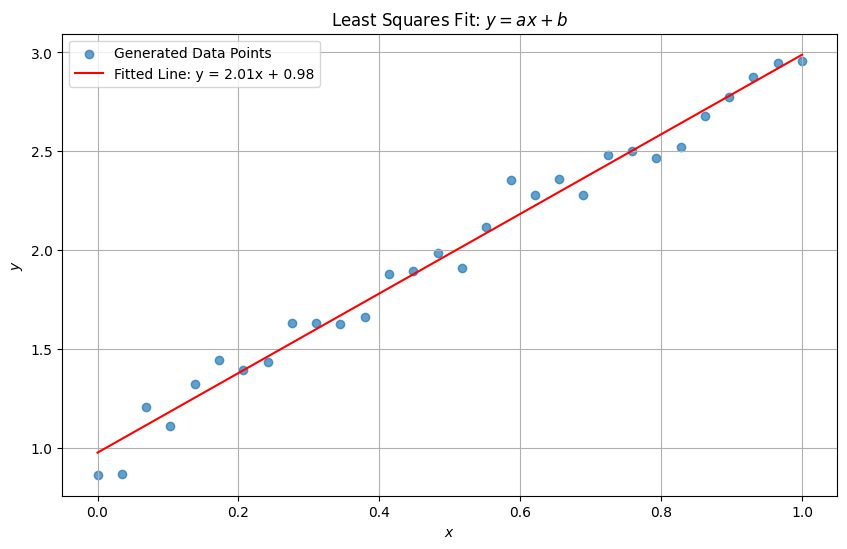

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Generated Data Points', alpha=0.7)

x_line = np.linspace(min(x), max(x), 100)
y_line = a_fit * x_line + b_fit
plt.plot(x_line, y_line, color='red', label=f'Fitted Line: y = {a_fit:.2f}x + {b_fit:.2f}')

plt.title('Least Squares Fit: $y = ax + b$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.grid(True)
plt.show()

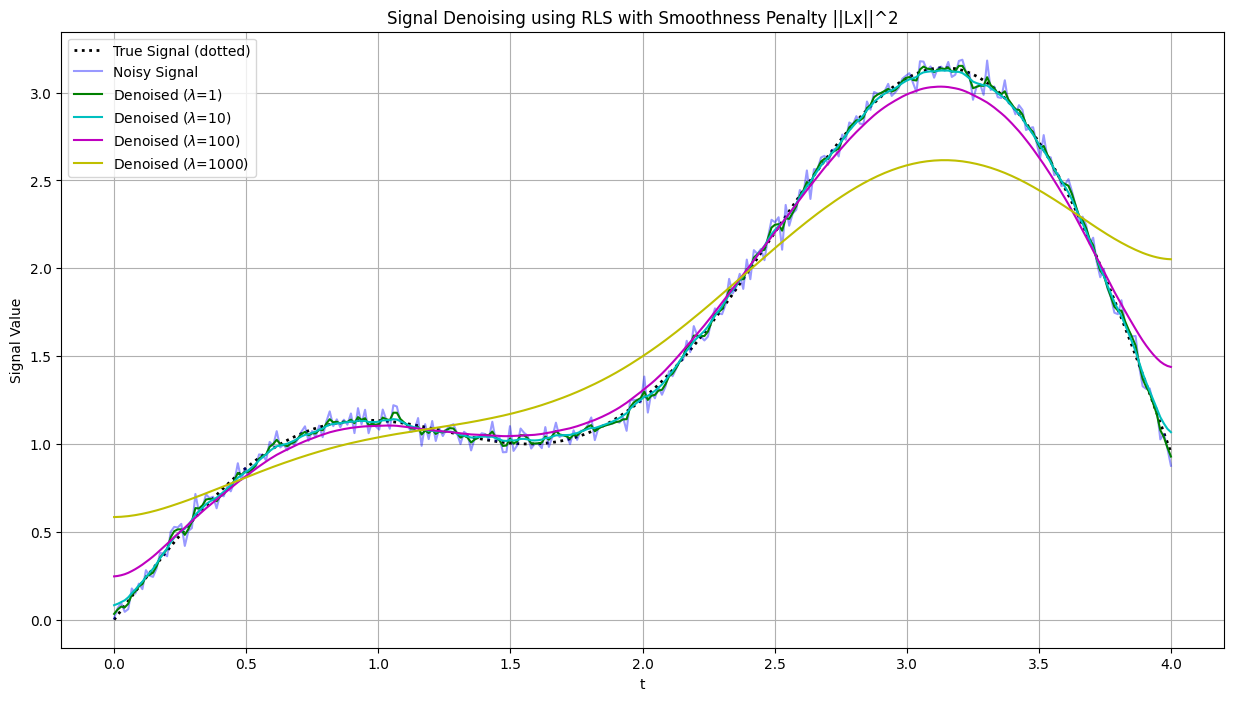

In [3]:
# 1. Generate the true signal x
t = np.linspace(0, 4, 300)
x = np.sin(t) + t * (np.cos(t)**2)

# 2. Add normally distributed noise to get b
np.random.seed(314)
noise = 0.05 * np.random.randn(300)
b = x + noise

# 3. Define regularization parameters and the smoothness operator
lambdas = [1, 10, 100, 1000]

n = len(t)
# First-order difference matrix L: (n-1) x n
# Lx = [x1-x0, x2-x1,...] - penalizes roughness
L = np.zeros((n-1, n))
L[:, 0:n-1] -= np.eye(n-1)
L[:, 1:n] += np.eye(n-1)

denoised_signals = {}
for lam in lambdas:
    A_reg = np.eye(n) + lam * (L.T @ L)
    x_rls = np.linalg.solve(A_reg, b) # better than inv()
    denoised_signals[lam] = x_rls

# 4. Plot
plt.figure(figsize=(15, 8))
plt.plot(t, x, 'k:', linewidth=2, label='True Signal (dotted)')
plt.plot(t, b, 'b-', alpha=0.4, label='Noisy Signal')

colors = ['g', 'c', 'm', 'y']
for i, lam in enumerate(lambdas):
    plt.plot(t, denoised_signals[lam], color=colors[i], linewidth=1.5,
             label=rf'Denoised ($\lambda$={lam})')

plt.title('Signal Denoising using RLS with Smoothness Penalty ||Lx||^2')
plt.xlabel('t')
plt.ylabel('Signal Value')
plt.legend()
plt.grid(True)
plt.show()